# EEG Alpha Waves dataset exploration

*Auxiliary notebook for the QMN TA team (signal-processing weeks 10-13)*

Loads `notebooks/data/alphawaves.npz`, the packaged version of the public release of
Cattan, Rodrigues & Congedo (GIPSA-lab 2017, Zenodo record 2348892), and walks through what is in it, so we can design the signal-processing
practicals (time series, Fourier and spectral analysis, filtering, PCA, linear algebra)
with the content clear in mind. It doubles as the visual check on the package: every
number and figure below comes from the shipped file, not from the raw `.mat` release.

**Full array documentation:** `notebooks/data/eeg_datadictionary.md`.

Key facts to keep in mind:

- **20 subjects**, one resting-state session each, **16 electrodes** (10-20 system),
  shipped at **256 Hz** in microvolts. Each session is **10 blocks of 10 s**, alternating
  **eyes closed** (5 blocks) and **eyes open** (5 blocks), so the file holds 200 blocks.
- The phenomenon is **occipital alpha blocking**, the classic Berger effect: 8-12 Hz
  power over O1/Oz/O2 is strong with the eyes closed and suppressed with the eyes open.
  It has about the best signal-to-noise ratio of anything in EEG, which is exactly what
  makes it teachable.
- The signal is shipped **raw on purpose**. It is DC-coupled, so every channel sits on a
  large constant offset; eyeblinks are still in there; 50 Hz line noise is present.
  Cleaning it up is the students' job, and it starts showing in section 2.
- **`subject_19` carries a 240 mV excursion on P4**, roughly ten times any other
  subject's peak. It comes from the original release and it is kept, because it wrecks
  any group average that does not deal with it.
- **19 of the 20 subjects show the effect** (section 8). The one that does not is useful:
  a real distribution to describe instead of a guaranteed result.
- The only build-time processing was decimation from 512 to 256 Hz, applied to the
  **continuous** session *before* the blocks were cut out of it.

In [1]:
# --- Imports + plot style
import numpy as np
from scipy.signal import welch, spectrogram, butter, filtfilt, hilbert, detrend
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
COND_COLOR = {"eyes_closed": "#5b2c83", "eyes_open": "#ff7f0e"}
ALPHA_BAND = (8.0, 12.0)
OCCIPITAL  = ["O1", "Oz", "O2"]

In [2]:
# --- Load the package: one npz, no allow_pickle, no MNE
d = np.load(Path("../notebooks/data/alphawaves.npz"))

X         = d["X"]                    # (blocks, channels, samples), microvolts
condition = d["condition"]            # eyes_closed / eyes_open, one per block
subject   = d["subject"]              # subject id, one per block
block     = d["block"]                # position of the block in its session, 1-10
onset_s   = d["onset_s"]              # block start in the original continuous recording
times     = d["times"]                # seconds within a block
ch_names  = list(d["ch_names"])
ch_xy     = d["ch_xy"]                # top-down topography coordinates
fs        = float(d["sfreq"])

BLOCK_S = X.shape[2] / fs             # 10 s, by construction
subs    = sorted(set(subject))

def ci(name):
    return ch_names.index(name)

def pick(subj=None, cond=None, name=None):
    "The blocks of one subject and/or condition, optionally cut down to one channel."
    m = np.ones(len(X), dtype=bool)
    if subj is not None:
        m &= subject == subj
    if cond is not None:
        m &= condition == cond
    return X[m] if name is None else X[m][:, ci(name), :]

def concat(subj, cond, name):
    "One long trace: the blocks of that subject and condition laid end to end."
    return np.concatenate(pick(subj, cond, name))

print("blocks: %d | channels: %d | samples: %d | %.0f Hz | blocks of %.0f s"
      % (X.shape[0], X.shape[1], X.shape[2], fs, BLOCK_S))
print("conditions:", {str(c): int((condition == c).sum()) for c in sorted(set(condition))})
print("subjects  : %d, from %s to %s" % (len(subs), subs[0], subs[-1]))
print("channels  :", ", ".join(ch_names))

blocks: 200 | channels: 16 | samples: 2560 | 256 Hz | blocks of 10 s
conditions: {'eyes_closed': 100, 'eyes_open': 100}
subjects  : 20, from subject_00 to subject_20
channels  : FP1, FP2, FC5, FC6, FZ, T7, CZ, T8, P7, P3, PZ, P4, P8, O1, Oz, O2


## The two extra arrays: `block` and `onset_s`

Both files in the bundle share the same seven arrays (`X`, `condition`, `subject`,
`times`, `ch_names`, `ch_xy`, `sfreq`). This one adds two more, because a resting-state
session has structure that a trial-locked one does not: `block` says where each block sat
in its session (1 to 10) and `onset_s` says when it started in the original recording.
Between them they recover the alternation the subject actually experienced, which is what
lets sections 1 and 4 put the blocks back onto a session time axis.

In [3]:
# --- Block layout of one subject, and the same check run over all of them
m = subject == "subject_00"
for b, c, o in zip(block[m], condition[m], onset_s[m]):
    print("  block %2d  %-11s starts at %7.2f s" % (b, c, o))

for s in subs:
    m = subject == s
    assert list(block[m]) == list(range(1, 11)), s          # ten blocks, in order
    assert np.all(np.diff(onset_s[m]) > 0), s               # onsets increase
    assert len(set(condition[m][::2])) == 1, s              # conditions alternate
print("\nall %d subjects: 10 blocks, increasing onsets, strict alternation" % len(subs))

  block  1  eyes_closed starts at   16.31 s
  block  2  eyes_open   starts at   27.08 s
  block  3  eyes_closed starts at   38.01 s
  block  4  eyes_open   starts at   50.15 s
  block  5  eyes_closed starts at   61.40 s
  block  6  eyes_open   starts at   71.65 s
  block  7  eyes_closed starts at   81.44 s
  block  8  eyes_open   starts at   91.60 s
  block  9  eyes_closed starts at  101.02 s
  block 10  eyes_open   starts at  111.01 s

all 20 subjects: 10 blocks, increasing onsets, strict alternation


## 1. The raw signal: oscillations you can see by eye

Before any spectral machinery, just plot the trace. Below is one occipital channel (Oz)
for all ten blocks of one subject, each drawn at its real `onset_s`, so the gaps in the
line are the pauses between blocks in the session. Even at this zoom the eyes-closed
blocks look visibly "thicker" (a sustained rhythm) and the eyes-open ones flatter.

Look at where the y axis sits, too: hundreds of microvolts away from zero. That is the
DC offset of an unfiltered recording, and it is the first thing anyone has to remove.

*Teaching hook (W12, time series): sampling rate, indexing by time, what a raw neural time series looks like.*

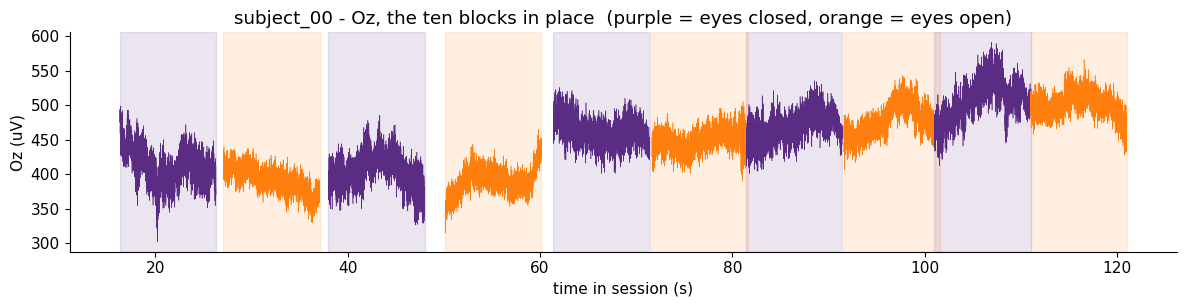

In [4]:
# --- Oz across the session, every block drawn at its real onset time
m = subject == "subject_00"
fig, ax = plt.subplots(figsize=(12, 3.2))
for start, trace, cond in zip(onset_s[m], X[m][:, ci("Oz"), :], condition[m]):
    ax.plot(start + times, trace, lw=0.4, color=COND_COLOR[cond])
    ax.axvspan(start, start + BLOCK_S, color=COND_COLOR[cond], alpha=0.12)
ax.set_xlabel("time in session (s)"); ax.set_ylabel("Oz (uV)")
ax.set_title("subject_00 - Oz, the ten blocks in place  (purple = eyes closed, orange = eyes open)")
plt.tight_layout(); plt.show()

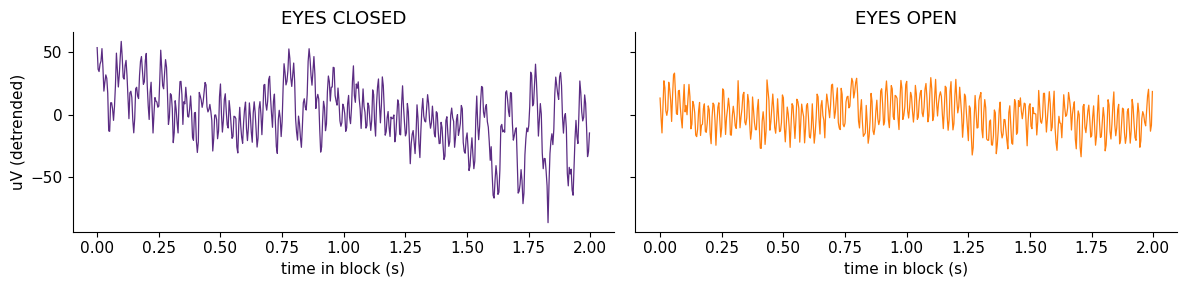

In [5]:
# --- Zoom: 2 s of eyes-closed vs 2 s of eyes-open at Oz (the ~10 Hz rhythm comes and goes)
seg = int(2 * fs)
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, cond in zip(axes, ["eyes_closed", "eyes_open"]):
    trace = detrend(pick("subject_00", cond, "Oz")[0][:seg], type="constant")   # drop the DC offset
    ax.plot(times[:seg], trace, lw=0.9, color=COND_COLOR[cond])
    ax.set_xlabel("time in block (s)"); ax.set_title(cond.replace("_", " ").upper())
axes[0].set_ylabel("uV (detrended)")
plt.tight_layout(); plt.show()

## 2. Eyeblink artifacts on the frontal channels

Frontal electrodes (FP1, FP2) sit right above the eyes and pick up a large, slow
deflection every time the subject blinks. These are the textbook **eyeblink artifacts**:
much bigger than the neural signal, and present only when the eyes are open. Ready-made
material for an artifact-detection exercise, and a natural motivation for PCA and ICA
later on.

Because the recording carries no online filter, each channel also sits on a large DC
offset, so we take it out with `detrend(..., type="constant")` before plotting, which is
itself a teaching point about baseline removal. We use `subject_08` here, who blinks
freely with the eyes open.

*Teaching hook (W12 artifacts and detrending; W11 PCA/ICA as artifact removal).*

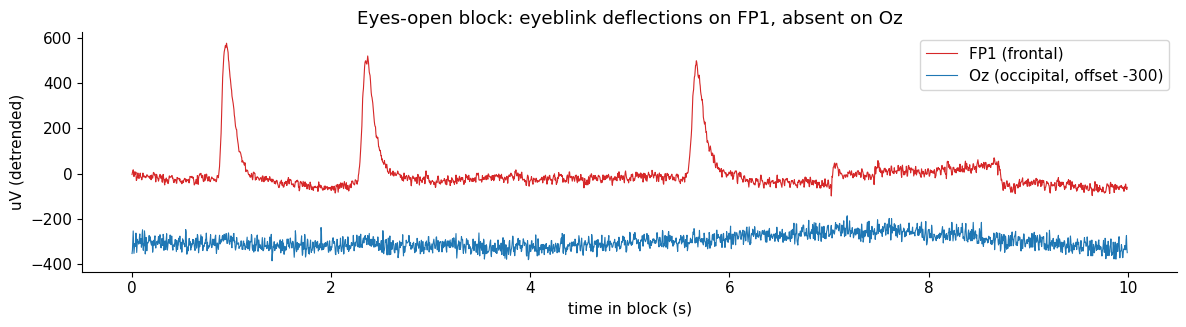

In [6]:
# --- FP1 vs Oz over one eyes-open block: blinks dominate frontal, not occipital
fp1 = detrend(pick("subject_08", "eyes_open", "FP1")[0], type="constant")
oz  = detrend(pick("subject_08", "eyes_open", "Oz")[0], type="constant")
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(times, fp1, lw=0.8, label="FP1 (frontal)", color="#d62728")
ax.plot(times, oz - 300, lw=0.8, label="Oz (occipital, offset -300)", color="#1f77b4")
ax.set_xlabel("time in block (s)"); ax.set_ylabel("uV (detrended)")
ax.set_title("Eyes-open block: eyeblink deflections on FP1, absent on Oz")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 3. The power spectrum: the alpha peak (Fourier)

Now the spectral view. We estimate the power spectral density with **Welch's method** on
the eyes-closed and eyes-open occipital data, each condition's five blocks laid end to
end. Eyes closed shows a sharp bump at about 10 Hz, the alpha peak; eyes open is close to
the broadband 1/f background with the bump gone. On the log-log axes the 50 Hz line noise
is visible as well, another thing the package deliberately leaves in.

*Teaching hook (W13, Fourier): FFT, amplitude and power spectra, Welch PSD, band power, the 1/f background.*

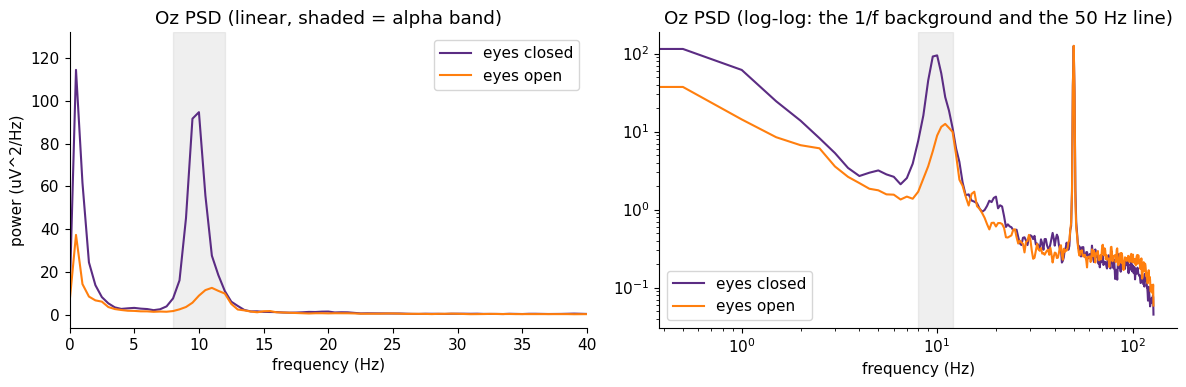

In [7]:
# --- Welch PSD of Oz, eyes closed vs eyes open
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cond in ["eyes_closed", "eyes_open"]:
    f, p = welch(concat("subject_00", cond, "Oz"), fs=fs, nperseg=int(2 * fs))
    axes[0].plot(f, p, color=COND_COLOR[cond], label=cond.replace("_", " "))
    axes[1].loglog(f, p, color=COND_COLOR[cond], label=cond.replace("_", " "))
for ax in axes:
    ax.axvspan(*ALPHA_BAND, color="grey", alpha=0.12)
    ax.set_xlabel("frequency (Hz)"); ax.legend()
axes[0].set_xlim(0, 40); axes[0].set_ylabel("power (uV^2/Hz)")
axes[0].set_title("Oz PSD (linear, shaded = alpha band)")
axes[1].set_title("Oz PSD (log-log: the 1/f background and the 50 Hz line)")
plt.tight_layout(); plt.show()

## 4. Time-frequency: the spectrogram (alpha comes and goes with the blocks)

One spectrogram of the whole Oz recording makes the story visible at once: a horizontal
band of power at about 10 Hz that switches **on during the eyes-closed blocks and off
during the eyes-open ones**. This is what ties the time-domain and frequency-domain views
together.

The package ships blocks rather than the continuous session, so here they are laid end to
end in presentation order and the pauses between them are gone. The block boundaries are
marked; the alternation is the same one section 1 plotted on the true time axis.

*Teaching hook (W13): spectrograms, time-frequency analysis, heatmaps and colormaps.*

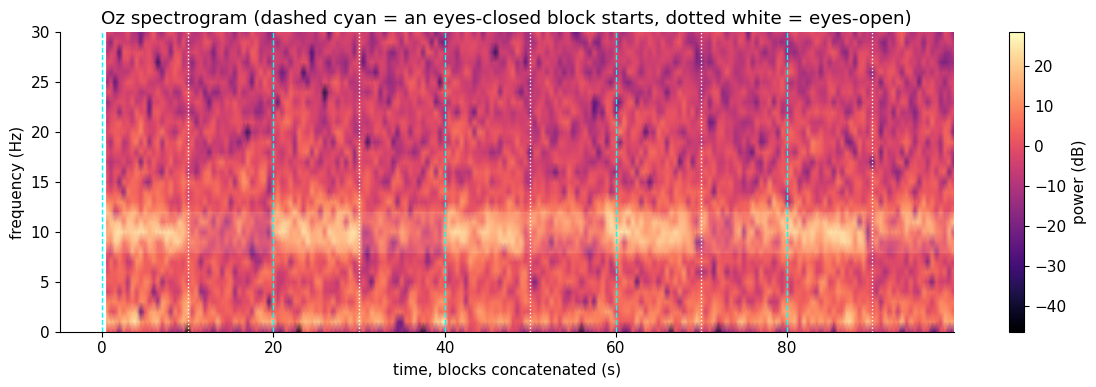

In [8]:
# --- Spectrogram of Oz with the ten blocks laid end to end, boundaries marked
m = subject == "subject_00"
trace = np.concatenate(X[m][:, ci("Oz"), :])          # presentation order, pauses removed
f, tt, Sxx = spectrogram(trace, fs=fs, nperseg=int(fs), noverlap=int(fs) // 2)
keep = f <= 30
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.pcolormesh(tt, f[keep], 10 * np.log10(Sxx[keep] + 1e-12),
                   shading="gouraud", cmap="magma")
for k, cond in enumerate(condition[m]):
    closed = cond == "eyes_closed"
    ax.axvline(k * BLOCK_S, color="cyan" if closed else "white",
               lw=1.0, ls="--" if closed else ":")
ax.axhspan(*ALPHA_BAND, color="white", alpha=0.10)
ax.set_xlabel("time, blocks concatenated (s)"); ax.set_ylabel("frequency (Hz)")
ax.set_title("Oz spectrogram (dashed cyan = an eyes-closed block starts, dotted white = eyes-open)")
fig.colorbar(im, ax=ax, label="power (dB)")
plt.tight_layout(); plt.show()

## 5. Band-pass filtering: isolating the alpha rhythm

A Butterworth **band-pass filter** (8-12 Hz, zero-phase through `filtfilt`) pulls the
alpha oscillation out of a single eyes-closed block, and its **Hilbert envelope** traces
the waxing and waning of the rhythm. A good vehicle for filter design, for phase
distortion and why zero-phase filtering matters, and for the analytic signal.

*Teaching hook (W13): filter application, band-pass, phase, envelope.*

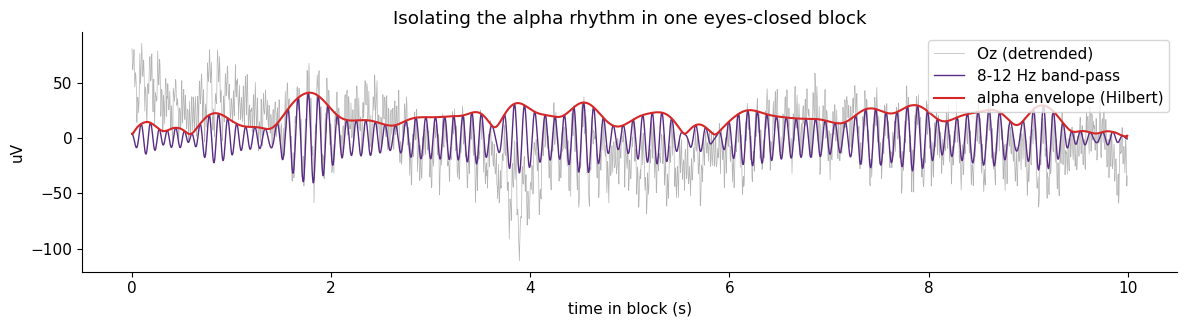

In [9]:
# --- Band-pass 8-12 Hz on one eyes-closed Oz block, plus the Hilbert envelope
b, a = butter(4, ALPHA_BAND, btype="band", fs=fs)
raw   = detrend(pick("subject_00", "eyes_closed", "Oz")[0], type="constant")
alpha = filtfilt(b, a, raw)
env   = np.abs(hilbert(alpha))
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(times, raw, lw=0.5, color="0.7", label="Oz (detrended)")
ax.plot(times, alpha, lw=1.0, color="#5b2c83", label="8-12 Hz band-pass")
ax.plot(times, env, lw=1.5, color="#d62728", label="alpha envelope (Hilbert)")
ax.set_xlabel("time in block (s)"); ax.set_ylabel("uV"); ax.legend(loc="upper right")
ax.set_title("Isolating the alpha rhythm in one eyes-closed block")
plt.tight_layout(); plt.show()

## 6. Where is the alpha? A scalp topography

Alpha band power per channel, eyes closed vs eyes open, drawn at the `ch_xy` positions
that ship with the package. The eyes-closed map lights up over the **posterior
(occipital and parietal)** electrodes, exactly where the dominant rhythm lives, and the
eyes-open map is flat. No MNE involved: the coordinates are in the file, so this is a
scatter plot with power as colour.

*Teaching hook: motivates spatial structure across channels, which leads to PCA (W11) and to the idea of a topography.*

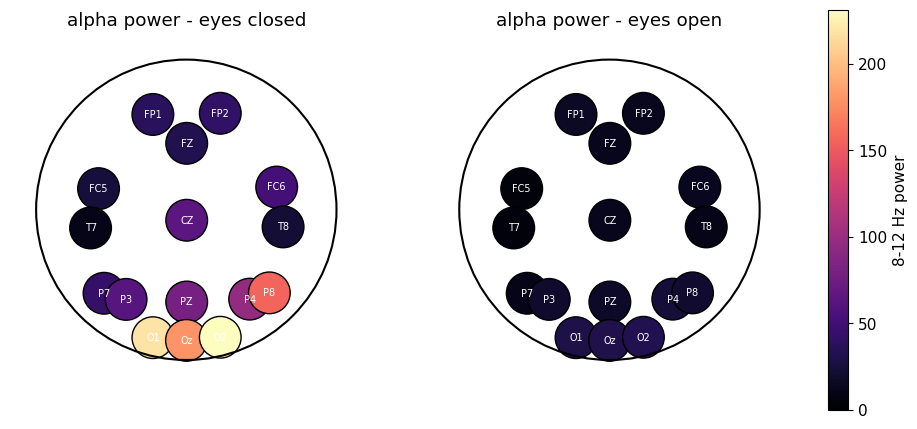

In [10]:
# --- Alpha band power per channel, drawn at the shipped ch_xy positions
def band_power(x, band=ALPHA_BAND, nperseg=None):
    "Power of a single-channel trace inside a frequency band, by Welch's method."
    f, p = welch(x, fs=fs, nperseg=nperseg or int(2 * fs))
    inside = (f >= band[0]) & (f <= band[1])
    return trapezoid(p[inside], f[inside])

maps = {cond: np.array([band_power(concat("subject_00", cond, name)) for name in ch_names])
        for cond in ["eyes_closed", "eyes_open"]}
vmax = max(v.max() for v in maps.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, cond in zip(axes, ["eyes_closed", "eyes_open"]):
    sc = ax.scatter(ch_xy[:, 0], ch_xy[:, 1], c=maps[cond], s=900,
                    cmap="magma", vmin=0, vmax=vmax, edgecolor="k")
    for (x, y), name in zip(ch_xy, ch_names):
        ax.annotate(name, (x, y), ha="center", va="center", fontsize=7, color="white")
    ax.add_patch(plt.Circle((0, 0), 1.15, fill=False, lw=1.5))
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title("alpha power - " + cond.replace("_", " "))
fig.colorbar(sc, ax=axes, label="8-12 Hz power", fraction=0.04)
plt.show()

## 7. PCA across channels: does the structure separate the conditions?

Treat each 1 s window as a 16-dimensional observation of **alpha power across channels**
and run **PCA**, here as a plain SVD of the standardised feature matrix rather than through
sklearn, since spelling it out is the point in a linear-algebra week. The first component
picks up the posterior-alpha axis, and projecting the windows onto PC1 and PC2 separates
eyes closed from eyes open largely along PC1, with some overlap in the middle. A direct
bridge from the linear-algebra weeks (covariance, SVD and eigendecomposition, projections)
to real multichannel data.

*Teaching hook (W10-W11): covariance matrix, PCA through SVD, scores and loadings, projection.*

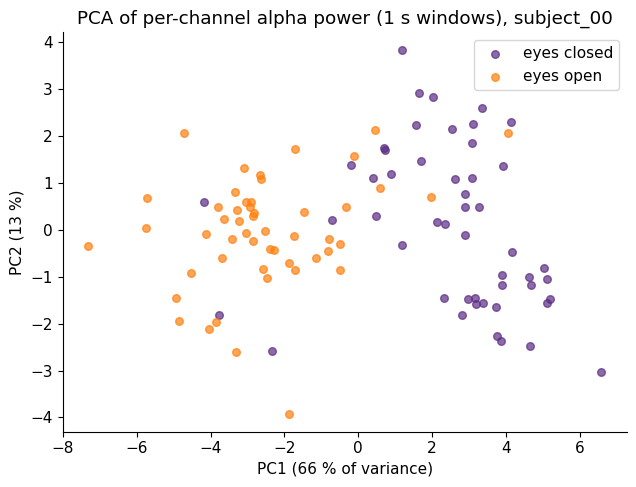

In [11]:
# --- Feature matrix: alpha power per channel in 1 s windows, labelled by condition
def alpha_windows(subj, cond, win_s=1):
    n = int(win_s * fs)
    rows = []
    for blk in pick(subj, cond):                        # each block, (channels, samples)
        for k in range(0, blk.shape[1] - n + 1, n):     # non-overlapping windows
            w = blk[:, k:k + n]
            rows.append([band_power(w[j], nperseg=n) for j in range(len(ch_names))])
    return np.array(rows)

Wc = alpha_windows("subject_00", "eyes_closed")
Wo = alpha_windows("subject_00", "eyes_open")
F  = np.log(np.vstack([Wc, Wo]) + 1e-3)                 # log-power stabilises the scale
y  = np.array([0] * len(Wc) + [1] * len(Wo))            # 0 = closed, 1 = open
F  = (F - F.mean(0)) / F.std(0)                         # standardise each channel

U, S, Vt = np.linalg.svd(F, full_matrices=False)        # PCA is the SVD of this matrix
pcs      = U[:, :2] * S[:2]                             # scores on the first two components
frac     = S ** 2 / np.sum(S ** 2)                      # variance explained per component

fig, ax = plt.subplots(figsize=(6.5, 5))
for lab, cond in [(0, "eyes_closed"), (1, "eyes_open")]:
    ax.scatter(pcs[y == lab, 0], pcs[y == lab, 1], c=COND_COLOR[cond], s=30, alpha=0.7,
               label=cond.replace("_", " "))
ax.set_xlabel("PC1 (%.0f %% of variance)" % (100 * frac[0]))
ax.set_ylabel("PC2 (%.0f %%)" % (100 * frac[1]))
ax.legend()
ax.set_title("PCA of per-channel alpha power (1 s windows), subject_00")
plt.tight_layout(); plt.show()

## 8. Group level: is the effect there in everyone?

Finally the alpha-blocking ratio, eyes-closed over eyes-open occipital alpha power, for
all 20 subjects. Nineteen of them show the effect (ratio above 1), and the strength varies
a lot: a few strong responders above 10x, weak ones around 1.5x, and one non-responder
whose ratio dips just below 1. That individual variability is pedagogically useful in its
own right, as a real distribution to describe, a genuine outlier to discuss, and a hook
back to the earlier stats weeks.

It is also the number quoted in the data dictionary, so it doubles as a check that the
file on disk is the one that was documented.

*Teaching hook: ties the signal-processing dataset back to descriptive stats and group comparison.*

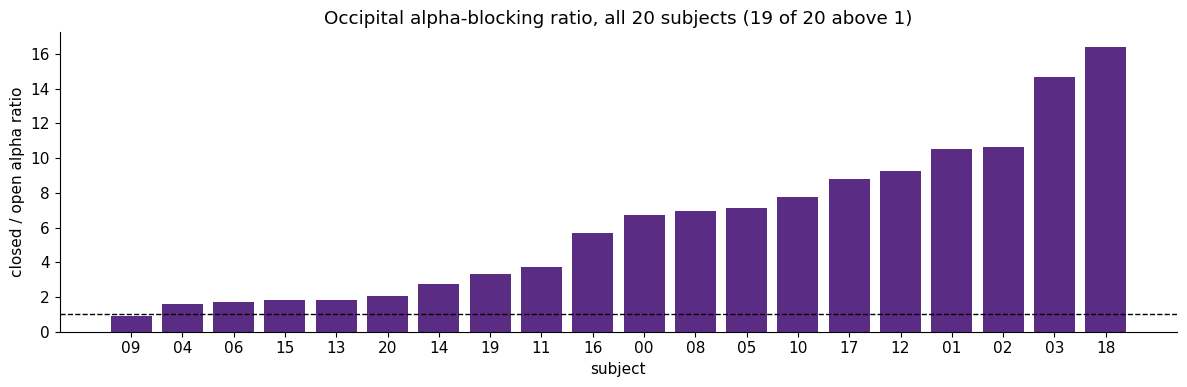

median ratio: 6.2   range: 0.9 to 16.4   above 1: 19/20
weakest: subject_09   strongest: subject_18


In [12]:
# --- Occipital (mean of O1/Oz/O2) alpha ratio, closed vs open, for every subject in the file
def occipital_alpha(subj, cond):
    return np.mean([band_power(concat(subj, cond, name)) for name in OCCIPITAL])

ratios = {s: occipital_alpha(s, "eyes_closed") / occipital_alpha(s, "eyes_open")
          for s in subs}
order  = sorted(ratios, key=ratios.get)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([s.replace("subject_", "") for s in order], [ratios[s] for s in order],
       color="#5b2c83")
ax.axhline(1, color="k", lw=1, ls="--")
ax.set_xlabel("subject"); ax.set_ylabel("closed / open alpha ratio")
above = sum(r > 1 for r in ratios.values())
ax.set_title("Occipital alpha-blocking ratio, all %d subjects (%d of %d above 1)"
             % (len(subs), above, len(subs)))
plt.tight_layout(); plt.show()

vals = np.array(list(ratios.values()))
print("median ratio: %.1f   range: %.1f to %.1f   above 1: %d/%d"
      % (np.median(vals), vals.min(), vals.max(), above, len(subs)))
print("weakest:", order[0], "  strongest:", order[-1])

## What this dataset can teach

| Technique / course week | Section above | Content |
|---|---|---|
| Raw time series, sampling, indexing by time (W12) | 1 | Visible oscillations |
| Artifacts and data cleaning (W12) | 2 | Clear eyeblinks on FP1/FP2 |
| FFT, Welch PSD, band power, 1/f (W13) | 3 | Textbook alpha peak |
| Spectrogram and time-frequency (W13) | 4 | Alpha on and off with the blocks |
| Filtering, phase, envelope (W13) | 5 | Clean band-pass demo |
| Topography and spatial structure | 6 | Posterior dominance, no MNE needed |
| PCA, covariance, SVD, projection (W10-W11) | 7 | The conditions separate on PC1 |
| Descriptive stats and group comparison (earlier weeks) | 8 | A real 20-subject effect with variability |

**Overall:** this dataset covers essentially every signal-processing technique in the back
half of the course with one clean, intuitive phenomenon, using numpy, scipy and
matplotlib only. The remaining gap is that it is resting-state: there are no task events, so there is
no ERP and no event-triggered average to be had here. That is exactly the gap
`erpcore_n170.npz` fills, and the pairing is the point. Averaging works on the N170
because it is phase-locked to a stimulus; averaging the blocks here would cancel the alpha
away, because the rhythm is ongoing and its phase is unrelated to when the block started.

**On the package itself:** everything above ran from the shipped `.npz` with numpy alone,
the `block` and `onset_s` arrays reproduce the session structure, the scalp coordinates
travel with the data, and and the group-level ratio comes out at the median 6.2 that the data
dictionary quotes. The raw `.mat` release is not needed to use any of this.